## Week 5: Introduction to Transformers
https://poloclub.github.io/transformer-explainer/
### 5.1: Self attention
Now that we understand how sequence information can be represented by vector embeddings, we can start building an intuition for how to embed the properties of text data into inductive biases suitable for training. 

Let us now consider a sequence of tokens represented by $x$.

\begin{equation*}
    x = \{ x_1, x_2, x_3, ... x_N \}
\end{equation*}

where $N$ refers to the maximum token size that can be accomodated in the context. The set $x$ is called the _context_. Each element of this set $x_i$ is a vector of size $(1,d)$ where $d$ is the size of embedding

An important property of sequence type of data is long-range dependancy of arbitrary length. A token $x_i$ can depend on any other token in context. How can we represent that? 


#### 5.1.1 Computing attention as a dot product
Long range dependancy between two input embeddings are computed as attention scores between them. Attention between two embedding vectors are computed as the dot product between them. When two vectors point in the same direction, they have higher dot product and therefore higher attention scores. 

Here is the formula for dot product. 

\begin{equation*}
    \vec{u} \cdot \vec{v} = |u| |v| cos(\theta)
\end{equation*}

where $\theta$ is the angle between two vectors. Play with the interactive sliders below to get an intuition for the relationship between alignment and the dot product between two vectors. 

In [2]:
from src.utils import interactive_dot_product

interactive_dot_product()

#### 5.1.2 Projecting inputs to low-dimensional space
Attention is computed between the projections of input embeddings. The different projections that we use are: 

- Query:    What does a token need? 
- Key:      What does a token provide? 

Attention is computed as the dot product between the Query and Key vectors of all input tokens. Attention between two embeddings is the dot product of what one vector wants and what the other can provide. The value vectors corresponding to each input token are then mixed with other value vectors using a weighted average.

The query, key and value vectors are computed using linear mapping using learned weight matrices $W_q$, $W_k$ and $W_v$ respectively. The query and key vectors are generally projected to a lower dimensional space within calculation of attention called the _head dimension_, $d_h$. So consequently the weight matrices for query and key have the shape $(d, d_h)$ Generally, $d_h$ and $d_v$ are the same. 

For an input vector $x_i$, the projections are computed as

\begin{equation*}
    q_i = x_i W_q
\end{equation*}

\begin{equation*}
    k_i = x_i W_k
\end{equation*}


In [16]:
import numpy as np
from src.utils import interactive_qk_vectors
x_1 = np.array([1.0, 0.5, -0.8])
x_2 = np.array([-0.4, 1.1, 1.2])
W_q = np.array([[0.92, -0.89], [0.94, 1.13], [-0.11, .99]])
W_k = np.array([[0.45, 0.67], [-0.56, 0.78], [1.23, -0.34]])
interactive_qk_vectors(x_1, x_2, W_q, W_k)

Output()

>> NEED TO CLARIFY
>> HERE WE ARE IMPOSING ROTATION SO BOTH Q1 AND Q2 ROTATE TOGETHER
>> It does not have to be that way. The angle between Q1 and Q2 can change depending on the weight matrix. What is common is that we impose the same weight matrix and this results in highlighting particular relationship between tokens.  So we need multiple heads. 


In this above demonstration, the input embedding vectors $x_1$ and $x_2$ are projected to corresponding query and key vectors $q_1, k_1$ and $q_2, k_2$ respectively. The weight matrices are shared across tokens. Maximising alignment between $q_1$ and $k_2$ hurts other alignments that might be present in the data. Thus, a single attention mechanism imposes shared geometric constraint over the tokens. As we will see later, this means we need multiple heads looking at different shared relationship across tokens to capture full relationship between the tokens. 

Next we will see how attention scores are used to mix contextual information between tokens. This is done by computing another projection called the value vector. This is again a linear projection of hte input embedding, computed using another learned weight matrix $W_v$. The value vectors are projected to $d_v$. The value matrix has the shape $(d, d_v)$. The shape of value vectors can be different from head dimension, but is typically set the same. 
\begin{equation*}
    v_i = x_i W_v
\end{equation*}

Run the following interactive to visualise all the three projections for the input embeddings mapped together. Here we use the head dimension to be 2 and is the same for value vector as well. 


In [17]:
from src.utils import interactive_qkv_vectors
W_v = np.array([[0.34, -0.56], [0.78, 0.12], [-0.45, 1.23]])
interactive_qkv_vectors(x_1, x_2, W_q, W_k, W_v)

Output()

#### 5.1.3 Computing output value vectors through attention 
Attention between $x_i$ and the other vectors in the input context is given by the scores:

\begin{equation*}
    A_i = \big[\, q_i \cdot k_j \,\big]_{j=1}^{N}
\end{equation*}

where $N$ is the size of the input sequence. These raw scores are normalised with a softmax to produce attention weights that sum to one:

\begin{equation*}
    \alpha_{ij} = \mathrm{softmax}_j\!\left(\frac{q_i \cdot k_j}{\sqrt{d_h}}\right)
              = \frac{\exp(q_i \cdot k_j / \sqrt{d_h})}{\sum_{l=1}^{N} \exp(q_i \cdot k_l / \sqrt{d_h})}
\end{equation*}

Finally, the output for token $i$ is the weighted average of all value vectors:

\begin{equation*}
    v_{i,\text{out}} = \sum_{j=1}^{N} \alpha_{ij}\, v_{j}
\end{equation*}

Run the next code cell to understand how context informs output value vectors. 

In [1]:
from src.utils import interactive_attention

interactive_attention()

Output()

#### 5.1.4 Projecting the attention output back to embedding space

The attention output for each token, $v_{i,\text{out}} = \sum_j \alpha_{ij} v_j$, is the
weighted sum of value vectors computed in the previous step. It lives in the value
space ($\mathbb{R}^{d_v}$) and must be projected back to the original embedding space
($\mathbb{R}^{d}$) before it can be passed on. A learned **output projection** $W_O$
does this:

\begin{equation*}
    x_{i,\text{out}} = v_{i,\text{out}} W_O 
\end{equation*}

where $W_O$ has shape $(d_v, d)$, the bias $b$ has shape $(1, d)$. 

Run the next code cell to see the attention output reflected back into the embedding space.

In [1]:
from src.utils import interactive_attention_with_output

interactive_attention_with_output()

Output()

#### 5.1.5 Attention head
Combine everything into a single python class

In [2]:
import numpy as np 
import torch
import torch.nn as nn

class SelfAttentionHead(nn.Module):
    def __init__(self, d_input, d_model,
                 project_output=True):
        """
        project_output : if True, apply an internal W_O mapping d_model -> d_input
                         (standalone head). Set False when used inside
                         MultiHeadAttention, where a single shared projection is
                         applied after concatenating the heads.
        """
        super().__init__()
        self.d_input = d_input
        self.d_model = d_model
        self.project_output = project_output

        self.W_Q = nn.Linear(d_input, d_model)
        self.W_K = nn.Linear(d_input, d_model)
        self.W_V = nn.Linear(d_input, d_model)
        self.W_O = nn.Linear(d_model, d_input) if project_output else None


    def forward(self, x, forward_mask=None, verbose=False, return_attention_weights=False):
        Q = self.W_Q(x); K = self.W_K(x); V = self.W_V(x)
        if verbose:
            print("Query shape:", Q.shape, " Key:", K.shape, " Value:", V.shape)

        A = Q @ K.transpose(-1, -2) / np.sqrt(self.d_model)
        if forward_mask is not None:
            A = A.masked_fill(~forward_mask, float("-inf"))
        A = A - A.amax(dim=-1, keepdim=True)
        A = torch.exp(A)
        A = A / A.sum(dim=-1, keepdim=True)

        output = A @ V                       # (batch, seq, d_model)
        if self.W_O is not None:
            output = self.W_O(output)        # -> (batch, seq, d_input)

        if return_attention_weights:
            return output, A
        return output


In [55]:
# Example usage
d_input = 12
d_model = 6
self_attention = SelfAttentionHead(d_input, d_model)
batch_size = 1
seq_length = 4
# Random input embedding vector
x = np.random.rand(batch_size, seq_length, d_input)
x = torch.tensor(x, dtype=torch.float32)
print("x shape:", x.shape)  # Should be (batch_size, seq_length, d_model)
output, attention_weights = self_attention.forward(x, verbose=True, return_attention_weights=True)

print("Output shape:", output.shape)  # Should be (batch_size, seq_length, d_model)
print("Attention weights shape:", attention_weights.shape)  # Should be (batch_size, seq_length, seq_length)



x shape: torch.Size([1, 4, 12])
Query shape: torch.Size([1, 4, 6])  Key: torch.Size([1, 4, 6])  Value: torch.Size([1, 4, 6])
Output shape: torch.Size([1, 4, 12])
Attention weights shape: torch.Size([1, 4, 4])


In [56]:
attention_weights.detach().numpy()

array([[[0.2364294 , 0.2544172 , 0.2734763 , 0.23567711],
        [0.24777803, 0.25156012, 0.26043364, 0.24022818],
        [0.24941076, 0.2627799 , 0.2560175 , 0.23179185],
        [0.25650126, 0.26327598, 0.25399068, 0.2262321 ]]], dtype=float32)

Text(0.5, 1.0, 'Attention Weights Heatmap')

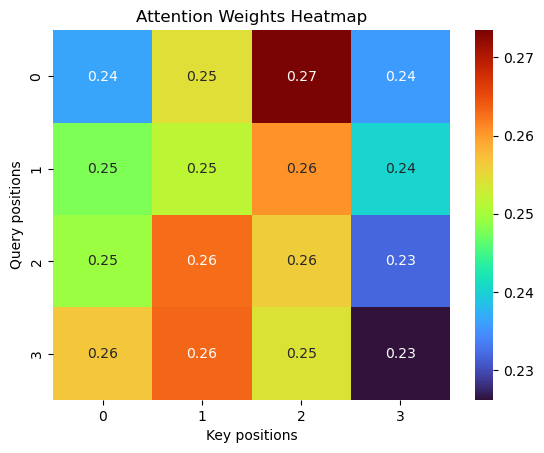

In [57]:
# show heatmap of attention weights
import seaborn as sns
import matplotlib.pyplot as plt

attention_numpy = attention_weights.detach().numpy()[0]  # (seq_length, seq_length)
sns.heatmap(attention_numpy, annot=True, cmap="turbo")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.title("Attention Weights Heatmap")

### 5.2 MultiHead Attention

In the code above, attention was calculated by taking all projections at once. In practice, it is more favorable to split the projections into different "heads" and attention is computed in each head in parallel. This allows for the attention mechanism to focus on different relationships in each head. 

Multi-head attention is computed by splitting the query, key and value vectors along the model dimension. So each head gets $d_{model}//n_{heads}$ sized vectors.  

In [58]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_input, d_model,
                 dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_input = d_input
        self.d_model = d_model
        self.d_head = d_model // n_heads

        # each head projects d_input -> d_head and does NOT apply its own W_O
        self.heads = nn.ModuleList([
            SelfAttentionHead(d_input, self.d_head, project_output=False)
            for _ in range(n_heads)
        ])
        # single shared output projection after concatenation: d_model -> d_input
        self.project_out = nn.Linear(d_model, d_input)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, forward_mask=None, verbose=False, return_attention_weights=False):
        head_outputs = []
        attn_weights = []
        for head in self.heads:
            if return_attention_weights:
                out_h, A_h = head(x, forward_mask, verbose, return_attention_weights)
                attn_weights.append(A_h)
            else:
                out_h = head(x, forward_mask, verbose)
            head_outputs.append(out_h)          # each (batch, seq, d_head)

        # concat heads along feature axis -> (batch, seq, d_model)
        concat = torch.cat(head_outputs, dim=-1)
        output = self.project_out(concat)       # -> (batch, seq, d_input)
        output = self.dropout(output)

        if return_attention_weights:
            attn = torch.stack(attn_weights, dim=1)
            return output, attn
        return output

In [59]:
msa_example = MultiHeadAttention(n_heads=2, d_input=d_input, d_model=d_model)
x = np.random.rand(batch_size, seq_length, d_input)
x = torch.tensor(x, dtype=torch.float32)
output, attention_weights = msa_example.forward(x, verbose=False, return_attention_weights=True)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")


Input shape: torch.Size([1, 4, 12])
Output shape: torch.Size([1, 4, 12])


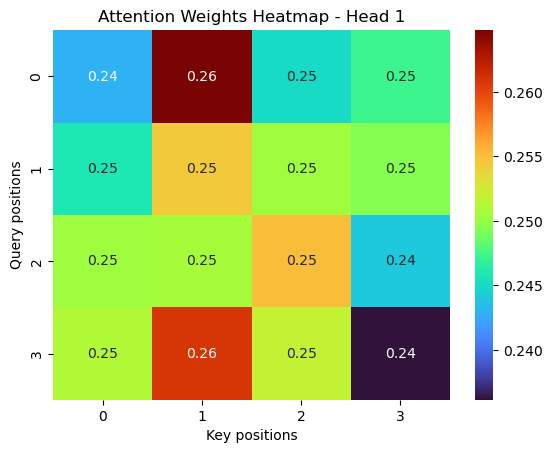

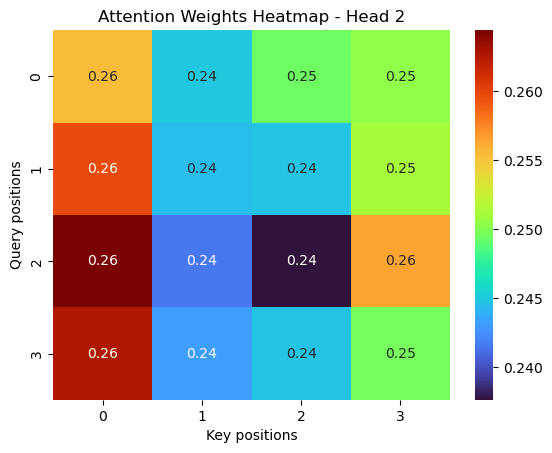

In [60]:
# Show two attention heatmaps, one per head

attention_numpy = attention_weights.detach().numpy()[0]  # (n_heads, seq_length, seq_length)
for i in range(attention_numpy.shape[0]):
    plt.figure()
    sns.heatmap(attention_numpy[i], annot=True, cmap="turbo")
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")
    plt.title(f"Attention Weights Heatmap - Head {i+1}")
    

### 5.3 Transformer block
A transformer block consists of the attention head and a Feedforward layer. The feedforward layer is a simple multi-layer perceptron and has two stages: one expansion and one compression. The expansion stage transforms $(1,d)$ shaped embedding into $(1,4d)$ in a typical transformer block. The compression stage puts it back to the original dimension. The MLP layer transforms on input at a time so the input and output shapes are always consistent. 


In [61]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout()
    
    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_input, d_model, d_ff):
        super().__init__()
        self.attention = MultiHeadAttention(n_heads, d_input, d_model)
        self.norm1 = nn.LayerNorm(d_input)
        self.ffn = FeedForward(d_input, d_ff)
        self.norm2 = nn.LayerNorm(d_input)

    def forward(self, x, return_attention_weights=False):
        if return_attention_weights:
            attn_output, attns = self.attention(x, return_attention_weights=return_attention_weights)
        else:
            attn_output = self.attention(x)
        x = self.norm1(x + attn_output)  # Residual connection + LayerNorm
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)    # Residual connection + LayerNorm
        if return_attention_weights:
            return x, attns
        else:
            return x

In [62]:
transformer_block = TransformerBlock(
    n_heads=2,
    d_input=d_input,
    d_model=d_model,
    d_ff=4 * d_input
)
x = np.random.rand(batch_size, seq_length, d_input)
x = torch.tensor(x, dtype=torch.float32)
output, attention_weights = transformer_block(x, return_attention_weights=True)
print(f"Input shape: {x.shape}")
print(f"Transformer block output shape: {output.shape}")


Input shape: torch.Size([1, 4, 12])
Transformer block output shape: torch.Size([1, 4, 12])


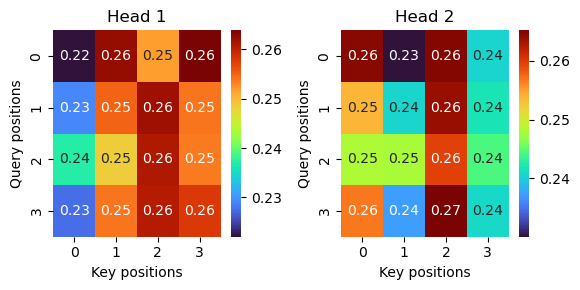

In [70]:
attention_weights_numpy = attention_weights.detach().numpy()[0]  # (n_heads, seq_length, seq_length)
fig, ax = plt.subplots(1, ncols=2, figsize=(6, 3))
for i in range(attention_weights_numpy.shape[0]):
    sns.heatmap(attention_weights_numpy[i], annot=True, cmap="turbo", ax=ax[i])
    ax[i].set_xlabel("Key positions")
    ax[i].set_ylabel("Query positions")
    ax[i].set_title(f"Head {i+1}")

fig.tight_layout()

### 5.4 Language Model

A language model is several multi-head attention transformers in series with each other. Deeper models capture increasingly abstract relationship between the tokens. The following table summarises the general shape of the transformer-based language models used in different applications 

>> Insert table TODO



In [64]:
class LanguageModel(nn.Module):
    def __init__(self, n_layers, n_head, d_model, d_input, d_ff):
        super().__init__()
        self.n_layers = n_layers
        self.n_head = n_head
        self.d_model = d_model 
        self.d_input = d_input 
        self.d_ff = d_ff 

        
        self.transformer_layers = nn.ModuleList([TransformerBlock(n_head, d_input, d_model, d_ff) 
                                        for _ in range(n_layers)])
        #self.transformer_blocks = nn.Sequential(*self.transformer_blocks_list)

    def forward(self, x, verbose=False, return_attention_weights=False):
        layer_outputs = []
        layer_attentions = []
        layer_out = x
        if return_attention_weights:
            for layer in self.transformer_layers:
                layer_out, layer_attn = layer(layer_out, return_attention_weights=return_attention_weights)
                layer_attentions.append(layer_attn)
            return layer_out, layer_attentions
        else: 
            for layer in self.transformer_layers:
                layer_out = layer(layer_out)
            
            return layer_out 
            
        
            
            
       

In [65]:
n_layers = 4
n_head = 2
lm_example = LanguageModel(n_layers=n_layers, n_head=n_head, 
                           d_model=d_model, d_input=d_input, 
                           d_ff=4*d_input
                        )

lm_output, attns = lm_example(x, return_attention_weights=True)

print(f"Input shape: {x.shape}")
print(f"Output shape: {lm_output.shape}")

Input shape: torch.Size([1, 4, 12])
Output shape: torch.Size([1, 4, 12])


In [66]:
attns[0].shape

torch.Size([1, 2, 4, 4])

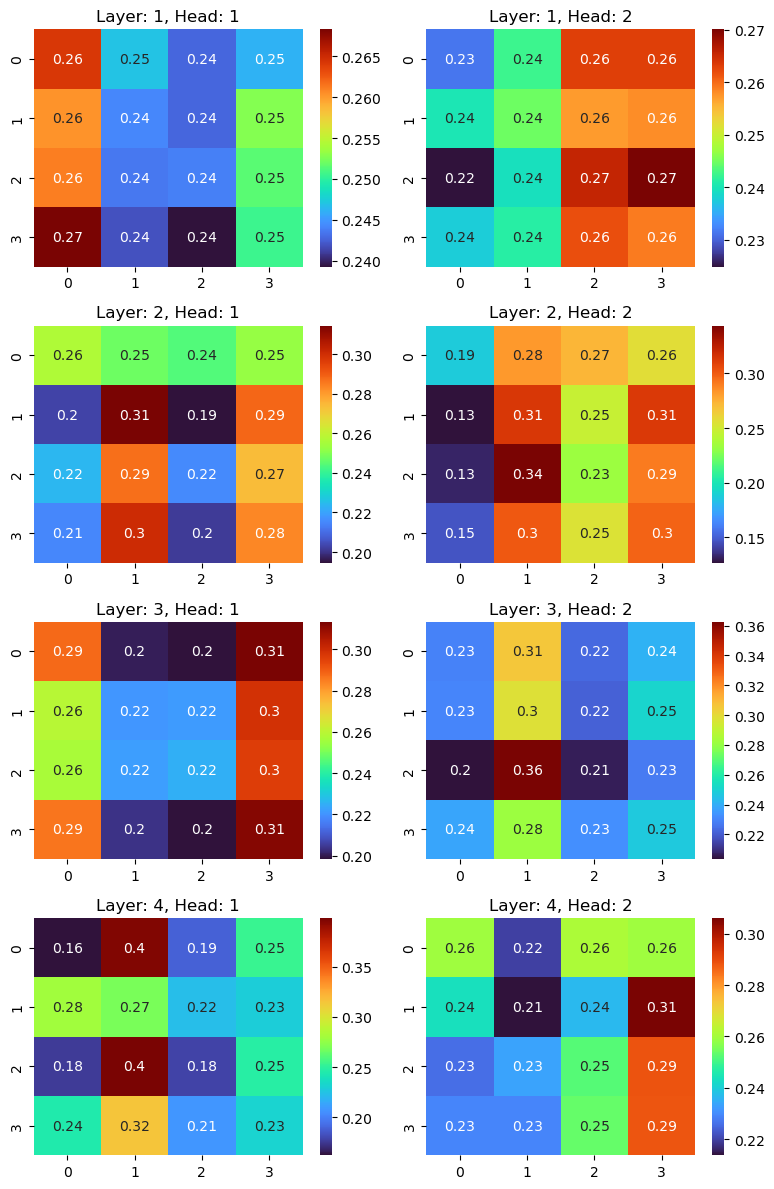

In [67]:
fig, ax = plt.subplots(nrows=n_layers, ncols=n_head, figsize=(8, 12))
for layer_num in range(n_layers):
    attentions_this_layer = attns[layer_num]
    for head_num in range(n_head):
        head_attention = attentions_this_layer[0,head_num]
        head_attention_numpy = head_attention.detach().numpy()
        sns.heatmap(head_attention_numpy, annot=True, cmap='turbo', ax=ax[layer_num, head_num])
        title_text = f"Layer: {layer_num+1}, Head: {head_num+1}"
        ax[layer_num, head_num].set_title(title_text)
fig.tight_layout()

In the next module, we will learn how to train language models from a large corpus of data. Since training on the entire UniProt is not feasible, we will only train a subset of them. But it is still good to reflect on what structural features are learnt by training a large model. 

### 5.5 Language Models capture long range relationships in sequence data

Does this architecture really capture any meaningful structural information present in the data? For this, we can have a look at an example. We will use ESM-2 model and see what happens when inputs flow through the network. We will observe the attention maps between layers. 



In [1]:
from transformers import AutoTokenizer, AutoModelForMaskedLM 
import torch
model_name = "facebook/esm2_t33_650M_UR50D"

model = AutoModelForMaskedLM.from_pretrained(model_name, attn_implementation="eager")
if torch.cuda.is_available():
    device="cuda"
elif torch.backends.mps.is_available():
    device="mps"
else:
    device="cpu"
device="cpu"
print(f"Using device: {device}")
model.to(device).eval();


Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


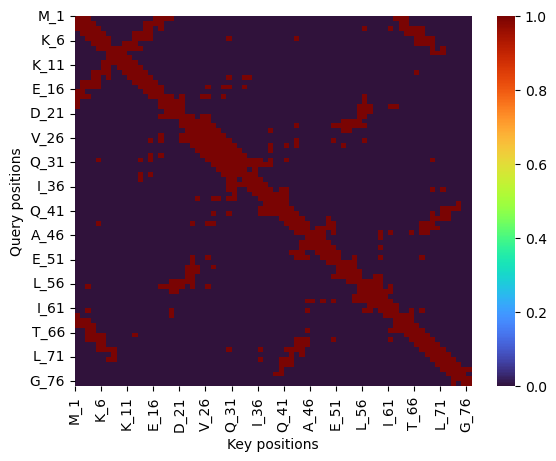

In [2]:
from src.esm_utils import tokenise_pdb_for_esm, pdb_to_contact_map, display_heatmap
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 
pdb_path = "/Users/alokbharadwaj/dev/ai4nanobiology/week_5/1UBQ.pdb"
tokenised_pdb = tokenise_pdb_for_esm(pdb_path, model_name=model_name)
contact_map = pdb_to_contact_map(pdb_path, distance=8)["contacts"]

display_heatmap(contact_map, tokenised_pdb)


In [3]:
input_tensor = tokenised_pdb['input_ids'].to(device)
with torch.no_grad():
    out = model(input_tensor, output_attentions=True)

In [4]:
attentions = out.attentions

In [10]:

def display_heatmaps(list_of_arrays, tokenised_pdb=None, cmap="turbo", titles=None):
    import matplotlib.pyplot as plt
    n = len(list_of_arrays)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    for i, array in enumerate(list_of_arrays):
        plt.sca(axes[i])
        display_heatmap(array, tokenised_pdb=tokenised_pdb, cmap=cmap)
        if titles is not None:
            axes[i].set_title(titles[i])
    
    fig.tight_layout()

Showing attention at Layer: 29, Head: 18
Shape of the attention matrix: (78, 78)


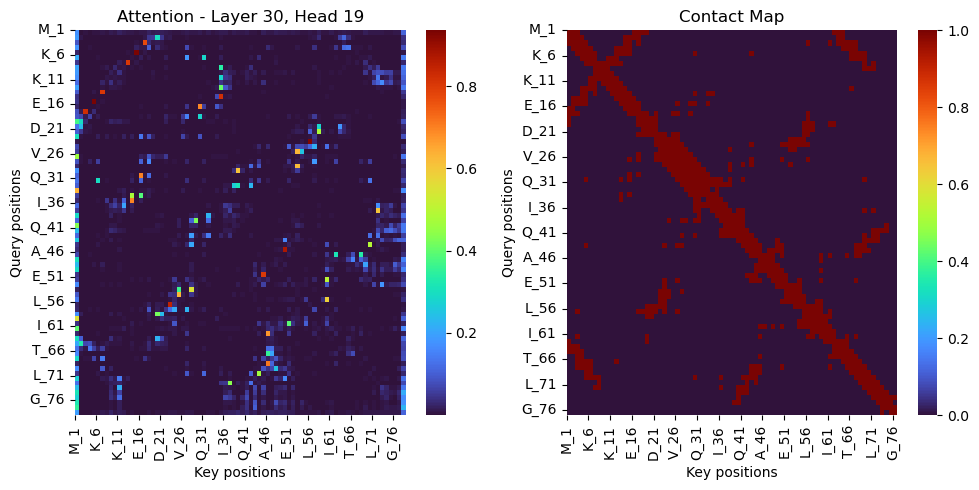

In [11]:

layer_to_plot = 29  # num_layers = 33, 0-indexed
head_to_plot = 18 # num_heads = 20, 0-indexed


attention_to_plot = attentions[layer_to_plot][0,head_to_plot].detach().numpy()
print(f"Showing attention at Layer: {layer_to_plot}, Head: {head_to_plot}")
print(f"Shape of the attention matrix: {attention_to_plot.shape}")
titles_to_display = [f"Attention - Layer {layer_to_plot+1}, Head {head_to_plot+1}", "Contact Map"]
display_heatmaps([attention_to_plot, contact_map], tokenised_pdb, titles=titles_to_display)


## Assignment 2: Evaluate structural information scores for different model parameters

1. Think of a way to measure the similarity between the contact map and the attention maps. Both are numpy arrays of equal shape. Using that define a function: 
```python
def similarity(attention_map, contact_map):
    # your code here
    # score = do something with the two arrays
    return score
```

2. Use the similarity() function to compute the distribution over all the heads in a given layer. The output should be a histogram. Show plots for atleast three different layers. 

3. Now, aggregate the distributions using mean and maximum. Then show a plot of how the similarity scores change with layer number. The result should be a 2-D plot with layer_num on the x-axis and the aggregated scores on the y axis. You should see two lines, one corresponding to the mean and the other corresponding to maximum. What does the trend tell you about the scores?
